# HDB Resale Price Regression — Notebook 14a: Final Model Diagnostics

Diagnostics for the story's final model: Log Model 11 + terrace interaction + cubic lease.

```r
lm(ln_price ~ town + flat_type + floor_area_sqm * is_terrace + storey_mid +
   remaining_lease_years + remaining_lease_sq + remaining_lease_cu +
   flat_model_grouped + dist_cbd_km + mrt_dist_m + hawker_dist_m +
   popular_school_dist_m + park_dist_m + hospital_dist_m +
   columbarium_dist_m + temple_dist_m + coast_dist_m +
   num_eights_tail + block_has_4 + month_factor)
```

Diagnostics: residuals vs fitted, Q-Q plot, Cook's distance, VIF, heteroskedasticity.

In [1]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(sandwich)
library(lmtest)
library(car)

df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
df$remaining_lease_sq <- df$remaining_lease_years^2
df$remaining_lease_cu <- df$remaining_lease_years^3
df$month_factor <- factor(format(df$month, '%Y-%m'))
df$ln_price <- log(df$resale_price)
df$is_terrace <- ifelse(df$flat_model_grouped == 'Terrace', 1, 0)

model_final <- lm(ln_price ~ town + flat_type + floor_area_sqm * is_terrace + storey_mid +
              remaining_lease_years + remaining_lease_sq + remaining_lease_cu +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m + park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m + coast_dist_m +
              num_eights_tail + block_has_4 +
              month_factor, data = df)

df$predicted <- exp(predict(model_final, df))
df$residual <- df$resale_price - df$predicted
df$resid_pct <- df$residual / df$predicted * 100

cat(sprintf('R² = %.4f, Params = %d, N = %s\n',
    summary(model_final)$r.squared, length(coef(model_final)),
    format(nrow(df), big.mark=',')))
cat(sprintf('Median AE = $%s\n', format(round(median(abs(df$residual), na.rm=TRUE)), big.mark=',')))
cat(sprintf('MAE = $%s\n', format(round(mean(abs(df$residual), na.rm=TRUE)), big.mark=',')))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


R² = 0.9403, Params = 88, N = 51,748


Median AE = $27,202


MAE = $36,825


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: carData

Attaching package: ‘car’

The following object is masked from ‘package:dplyr’:

    recode

The following object is masked from ‘package:purrr’:

    some



## 1. Residuals vs fitted

Random scatter = good. Funnel shape = heteroskedasticity. Curves = misspecification.

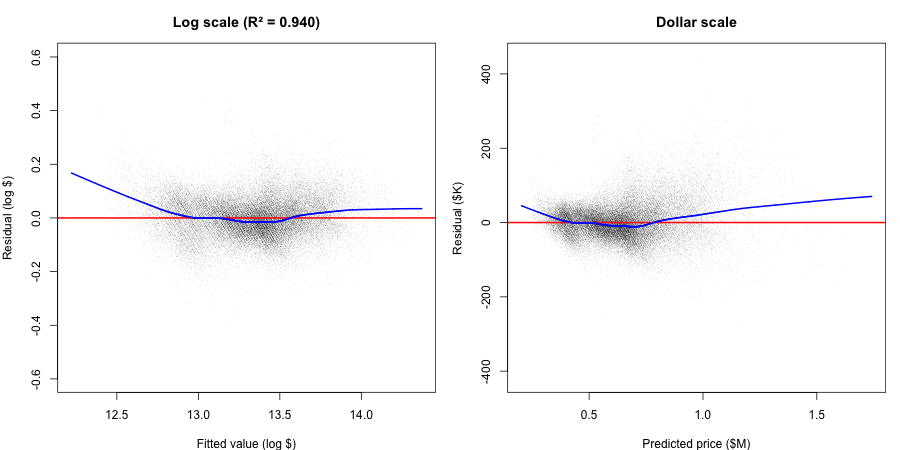

In [3]:
%%R -w 900 -h 450
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Log scale (model's native scale)
plot(fitted(model_final), resid(model_final),
     pch = '.', col = rgb(0, 0, 0, 0.05),
     xlab = 'Fitted value (log $)', ylab = 'Residual (log $)',
     main = sprintf('Log scale (R² = %.3f)', summary(model_final)$r.squared))
abline(h = 0, col = 'red', lwd = 2)
lines(lowess(fitted(model_final), resid(model_final), f = 0.2), col = 'blue', lwd = 2)

# Dollar scale (exponentiated)
plot(df$predicted / 1e6, df$residual / 1e3,
     pch = '.', col = rgb(0, 0, 0, 0.05),
     xlab = 'Predicted price ($M)', ylab = 'Residual ($K)',
     main = 'Dollar scale')
abline(h = 0, col = 'red', lwd = 2)
valid <- !is.na(df$predicted) & !is.na(df$residual)
lines(lowess(df$predicted[valid] / 1e6, df$residual[valid] / 1e3, f = 0.2), col = 'blue', lwd = 2)

## 2. Q-Q plot

Tests whether residuals are normally distributed. The middle should track the line; heavy tails are expected for housing data.

Skewness: 0.179


Kurtosis: 4.745 (normal = 3)


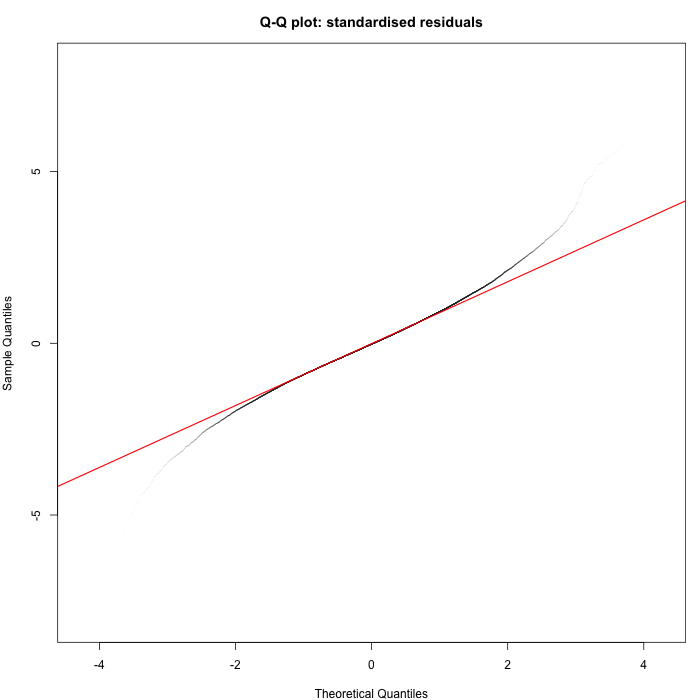

In [4]:
%%R -w 700 -h 700
par(mar = c(4, 4, 3, 1))

std_resid <- rstandard(model_final)
qqnorm(std_resid, pch = 16, cex = 0.2,
       col = rgb(0.15, 0.15, 0.15, 0.07),
       main = 'Q-Q plot: standardised residuals')
qqline(std_resid, col = 'red', lwd = 1.5)

cat(sprintf('Skewness: %.3f\n', mean((std_resid - mean(std_resid))^3) / sd(std_resid)^3))
cat(sprintf('Kurtosis: %.3f (normal = 3)\n', mean((std_resid - mean(std_resid))^4) / sd(std_resid)^4))

## 3. Influential points (Cook's distance)

Cook's D measures how much the entire model would change if one transaction were removed. High Cook's D = the observation is pulling the regression line toward it.

Threshold: 4/n

In [5]:
%%R
cooks_d <- cooks.distance(model_final)
threshold <- 4 / nrow(df)

cat(sprintf('Threshold (4/n): %.6f\n', threshold))
cat(sprintf('Observations above threshold: %d (%.1f%%)\n',
    sum(cooks_d > threshold, na.rm=TRUE),
    mean(cooks_d > threshold, na.rm=TRUE) * 100))
cat(sprintf('Max Cook\'s D: %.4f (%.0fx threshold)\n\n',
    max(cooks_d, na.rm=TRUE), max(cooks_d, na.rm=TRUE) / threshold))

# Top 20 most influential
df$cooks_d <- NA
df$cooks_d[as.integer(names(cooks_d))] <- cooks_d

top20 <- df[order(-df$cooks_d, na.last=TRUE), ][1:20, ]

cat(sprintf('%-5s %-30s %-10s %10s %10s %8s %10s\n',
    'Rank', 'Address', 'Type', 'Actual', 'Predicted', 'Error', 'Cook\'s D'))
cat(paste(rep('-', 90), collapse = ''), '\n')

for (j in 1:20) {
    r <- top20[j, ]
    label <- sprintf('Blk %s %s', r$block, substr(r$street_name, 1, 18))
    cat(sprintf('%-5d %-30s %-10s $%9s $%9s %+7.1f%% %10.6f\n',
        j, label, r$flat_type,
        format(round(r$resale_price), big.mark=','),
        format(round(r$predicted), big.mark=','),
        r$resid_pct, r$cooks_d))
}

Threshold (4/n): 0.000077


Observations above threshold: 2709 (5.2%)


Max Cook's D: 0.2718 (3516x threshold)



Rank  Address                        Type           Actual  Predicted    Error   Cook's D


------------------------------------------------------------------------------------------

...

16    Blk 7 TELOK BLANGAH CRES       1 ROOM     $    3e+05 $  264,906   +13.2%   0.002132


17    Blk 1 BEACH RD                 5 ROOM     $  912,000 $1,177,721   -22.6%   0.002061


18    Blk 826 TAMPINES ST 81         EXECUTIVE  $1,120,000 $1,421,148   -21.2%   0.002050


19    Blk 1E CANTONMENT RD           5 ROOM     $1,515,000 $1,137,686   +33.2%   0.002039


20    Blk 53 JLN MA'MOR              3 ROOM     $1,120,000 $  977,684   +14.6%   0.001992


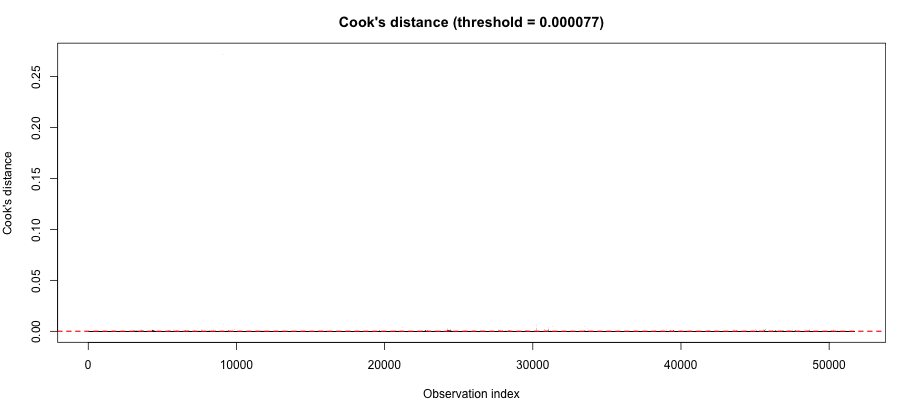

In [6]:
%%R -w 900 -h 400
par(mar = c(4, 4, 3, 1))

plot(cooks_d, pch = '.', col = rgb(0, 0, 0, 0.1),
     ylab = "Cook's distance", xlab = 'Observation index',
     main = sprintf("Cook's distance (threshold = %.6f)", threshold))
abline(h = threshold, col = 'red', lwd = 1.5, lty = 2)

## 4. Robustness: Cook's D removal

Re-run the model after removing all observations above the Cook's D threshold. Do the superstition coefficients survive?

In [7]:
%%R
df_complete <- df[complete.cases(df[, c('ln_price','town','flat_type','floor_area_sqm',
    'is_terrace','storey_mid','remaining_lease_years','remaining_lease_sq',
    'remaining_lease_cu','flat_model_grouped','dist_cbd_km','mrt_dist_m','hawker_dist_m',
    'popular_school_dist_m','park_dist_m','hospital_dist_m',
    'columbarium_dist_m','temple_dist_m','coast_dist_m',
    'num_eights_tail','block_has_4')]), ]

cooks_d2 <- cooks.distance(lm(ln_price ~ town + flat_type + floor_area_sqm * is_terrace + storey_mid +
              remaining_lease_years + remaining_lease_sq + remaining_lease_cu +
              flat_model_grouped + dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m + park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m + coast_dist_m +
              num_eights_tail + block_has_4 + month_factor, data = df_complete))

keep <- cooks_d2 <= 4/nrow(df_complete)
df_clean <- df_complete[keep, ]
n_removed <- sum(!keep)

model_clean <- lm(ln_price ~ town + flat_type + floor_area_sqm * is_terrace + storey_mid +
              remaining_lease_years + remaining_lease_sq + remaining_lease_cu +
              flat_model_grouped + dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m + park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m + coast_dist_m +
              num_eights_tail + block_has_4 + month_factor, data = df_clean)

robust_full <- coeftest(model_final, vcov = vcovHC(model_final, type = 'HC1'))
robust_clean <- coeftest(model_clean, vcov = vcovHC(model_clean, type = 'HC1'))
median_price <- median(df$resale_price)

cat(sprintf('Removed: %d influential transactions (%.1f%%)\n',
    n_removed, n_removed / nrow(df_complete) * 100))
cat(sprintf('R² full:  %.4f\n', summary(model_final)$r.squared))
cat(sprintf('R² clean: %.4f\n\n', summary(model_clean)$r.squared))

cat(sprintf('%-25s %15s %15s\n', '', 'Full model', 'Cook D removed'))
cat(paste(rep('-', 57), collapse = ''), '\n')
for (v in c('num_eights_tail', 'block_has_4')) {
    c1 <- robust_full[v, 'Estimate'] * median_price
    c2 <- robust_clean[v, 'Estimate'] * median_price
    p1 <- robust_full[v, 'Pr(>|t|)']
    p2 <- robust_clean[v, 'Pr(>|t|)']
    cat(sprintf('%-25s $%+12.0f (p=%.4f)  $%+12.0f (p=%.4f)\n', v, c1, p1, c2, p2))
}

Removed: 2709 influential transactions (5.2%)


R² full:  0.9403


R² clean: 0.9555



                               Full model  Cook D removed


---------------------------------------------------------

num_eights_tail           $       +1577 (p=0.0000)  $       +1696 (p=0.0000)


block_has_4               $       -8518 (p=0.0000)  $       -6722 (p=0.0000)


## 5. Heteroskedasticity

Breusch-Pagan test. If significant, the residual variance is not constant — which is why we use HC1 robust standard errors throughout.

In [8]:
%%R
bp <- bptest(model_final)
cat(sprintf('Breusch-Pagan test:\n'))
cat(sprintf('  Statistic: %.1f\n', bp$statistic))
cat(sprintf('  df: %d\n', bp$parameter))
cat(sprintf('  p-value: %s\n', format.pval(bp$p.value)))
cat(sprintf('\nVerdict: %s\n',
    ifelse(bp$p.value < 0.05,
        'Heteroskedasticity detected — HC1 robust SEs are justified.',
        'No evidence of heteroskedasticity.')))

Breusch-Pagan test:


  Statistic: 4640.6


  df: 86


  p-value: < 2.22e-16



Verdict: Heteroskedasticity detected — HC1 robust SEs are justified.


## 6. Alamak flats and bargain flats

The 20 transactions the model gets most wrong in each direction. These represent factors the model cannot see: renovation quality, heritage charm, views, distress sales.

In [9]:
%%R
cat('=== TOP 20 ALAMAK FLATS (sold way above prediction) ===\n\n')
cat(sprintf('%-5s %-30s %-10s %-8s %10s %10s %8s\n',
    'Rank', 'Address', 'Type', 'Storey', 'Actual', 'Predicted', 'Error'))
cat(paste(rep('-', 85), collapse = ''), '\n')

alamak <- df[order(-df$resid_pct), ]
for (j in 1:20) {
    r <- alamak[j, ]
    label <- sprintf('Blk %s %s', r$block, substr(r$street_name, 1, 18))
    cat(sprintf('%-5d %-30s %-10s %-8s $%9s $%9s %+7.1f%%\n',
        j, label, r$flat_type, r$storey_range,
        format(round(r$resale_price), big.mark=','),
        format(round(r$predicted), big.mark=','),
        r$resid_pct))
}

cat('\n\n=== TOP 20 BARGAIN FLATS (sold way below prediction) ===\n\n')
cat(sprintf('%-5s %-30s %-10s %-8s %10s %10s %8s\n',
    'Rank', 'Address', 'Type', 'Storey', 'Actual', 'Predicted', 'Error'))
cat(paste(rep('-', 85), collapse = ''), '\n')

bargain <- df[order(df$resid_pct), ]
for (j in 1:20) {
    r <- bargain[j, ]
    label <- sprintf('Blk %s %s', r$block, substr(r$street_name, 1, 18))
    cat(sprintf('%-5d %-30s %-10s %-8s $%9s $%9s %+7.1f%%\n',
        j, label, r$flat_type, r$storey_range,
        format(round(r$resale_price), big.mark=','),
        format(round(r$predicted), big.mark=','),
        r$resid_pct))
}

=== TOP 20 ALAMAK FLATS (sold way above prediction) ===



Rank  Address                        Type       Storey       Actual  Predicted    Error


-------------------------------------------------------------------------------------

1     Blk 5 CHANGI VILLAGE RD        3 ROOM     04 TO 06 $  495,000 $  270,828   +82.8%


2     Blk 5 CHANGI VILLAGE RD        3 ROOM     01 TO 03 $  438,000 $  269,143   +62.7%


...

16    Blk 44 BENDEMEER RD            3 ROOM     10 TO 12 $  339,000 $  478,256   -29.1%


17    Blk 43 BENDEMEER RD            3 ROOM     01 TO 03 $  328,000 $  460,963   -28.8%


18    Blk 23B QUEEN'S CL             4 ROOM     07 TO 09 $    4e+05 $  556,380   -28.1%


19    Blk 62 LOR 4 TOA PAYOH         4 ROOM     04 TO 06 $  590,000 $  819,133   -28.0%


20    Blk 8 EMPRESS RD               3 ROOM     10 TO 12 $  438,000 $  607,089   -27.9%
